In [1]:
# ==========================================================
# CREATE BALANCED DATASET DIRECTORY
# ==========================================================
print("start")

import os







start


In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("TensorFlow Version: ", tf.__version__)

Num GPUs Available:  1
TensorFlow Version:  2.10.0


In [3]:
# ==========================================================
# IMPORTS
# ==========================================================
print("start")

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
import tensorflow_addons as tfa
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    Callback
)

print("done1")

start
done1


In [4]:
# ==========================================================
# CONFIGURATION & GENERATORS
# ==========================================================
print("start")

# Pointing to the Balanced Dataset

IMAGE_SIZE = (288, 288)
MODEL_INPUT_SIZE = (288, 288, 3) # Added for your function
NUM_CLASSES = 3                  # Added for your function
BATCH_SIZE = 32
EPOCHS = 150

print("done1")

start
done1


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import preprocess_input

# 1. Define the base generator (No validation_split needed here anymore)
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# 2. Define the paths to your new split folders
train_dir = r"D:\Thesis_folder\Preprocessed_Pipeline\Supervised_Balanced\train"
val_dir = r"D:\Thesis_folder\Preprocessed_Pipeline\Supervised_Balanced\val"
test_dir = r"D:\Thesis_folder\Preprocessed_Pipeline\Supervised_Balanced\test"

# 3. Create the Train Generator
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(288, 288),
    batch_size=32,
    class_mode='categorical',
    shuffle=True # Shuffle training data
)

# 4. Create the Validation Generator
val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=(288, 288),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# 5. Create the Test Generator (CRITICAL: shuffle=False for evaluation)
test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(288, 288),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 18000 images belonging to 3 classes.
Found 2965 images belonging to 3 classes.
Found 2943 images belonging to 3 classes.


In [6]:
print("start")

from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.optimizers import Adam

f1_metric = tfa.metrics.F1Score(num_classes=NUM_CLASSES, average='macro', name='f1_score')
precision_metric = Precision(name='precision')
recall_metric = Recall(name='recall')

def get_InceptionV3():
    base_model = InceptionV3(
        input_shape=MODEL_INPUT_SIZE,
        weights='imagenet',
        include_top=False
    )

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)

    optimizer = Adam(learning_rate=0.0001)

    model.compile(
        loss="categorical_crossentropy",
        metrics=["accuracy", f1_metric, precision_metric, recall_metric],
        optimizer=optimizer
    )

    return model

model = get_InceptionV3()
model.summary()

print("done1")

start
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 288, 288, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 143, 143, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 143, 143, 32  96         ['conv2d[0][0]']                 
 alization)                     )                                                       

In [7]:
# ==========================================================
# CALLBACKS (Monitor set to 'val_f1_score')
# ==========================================================
print("start")

early_stop = EarlyStopping(
    monitor='val_f1_score',
    mode='max',
    patience=11,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_f1_score',
    mode='max',
    factor=0.3,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
"InceptionV3_balanced_model_V3.h5",
    monitor='val_f1_score',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("done")

start
done


In [8]:
# ==========================================================
# SHOW LEARNING RATE
# ==========================================================
print("start")

class PrintLearningRate(Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy()
        print(f"\nEpoch {epoch+1} Learning Rate : {lr}")

lr_callback = PrintLearningRate()

print("done1")

start
done1


In [9]:
# ==========================================================
# TRAINING
# ==========================================================
print("start")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint,
        lr_callback
    ]
)
print("done")

start
Epoch 1/150
563/563 [==============================] - ETA: 0s - loss: 0.9934 - accuracy: 0.5027 - f1_score: 0.4989 - precision: 0.6125 - recall: 0.2373
Epoch 1: val_f1_score improved from -inf to 0.55005, saving model to InceptionV3_balanced_model_V3.h5

Epoch 1 Learning Rate : 9.999999747378752e-05
563/563 [==============================] - 165s 286ms/step - loss: 0.9934 - accuracy: 0.5027 - f1_score: 0.4989 - precision: 0.6125 - recall: 0.2373 - val_loss: 0.9204 - val_accuracy: 0.5558 - val_f1_score: 0.5501 - val_precision: 0.6744 - val_recall: 0.3521 - lr: 1.0000e-04
Epoch 2/150
563/563 [==============================] - ETA: 0s - loss: 0.8800 - accuracy: 0.5912 - f1_score: 0.5832 - precision: 0.6759 - recall: 0.4063
Epoch 2: val_f1_score improved from 0.55005 to 0.57319, saving model to InceptionV3_balanced_model_V3.h5

Epoch 2 Learning Rate : 9.999999747378752e-05
563/563 [==============================] - 159s 283ms/step - loss: 0.8800 - accuracy: 0.5912 - f1_score: 0.5832

In [10]:

model = get_InceptionV3()

# 2. Load the weights directly into the blueprint
# Note: .load_weights() does not require a custom_objects dictionary!
model.load_weights("InceptionV3_balanced_model_V3.h5")

start


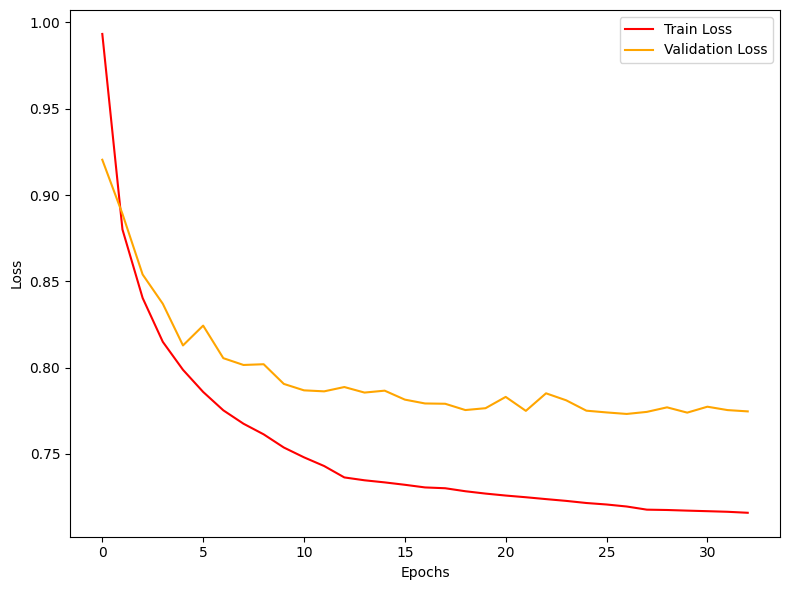

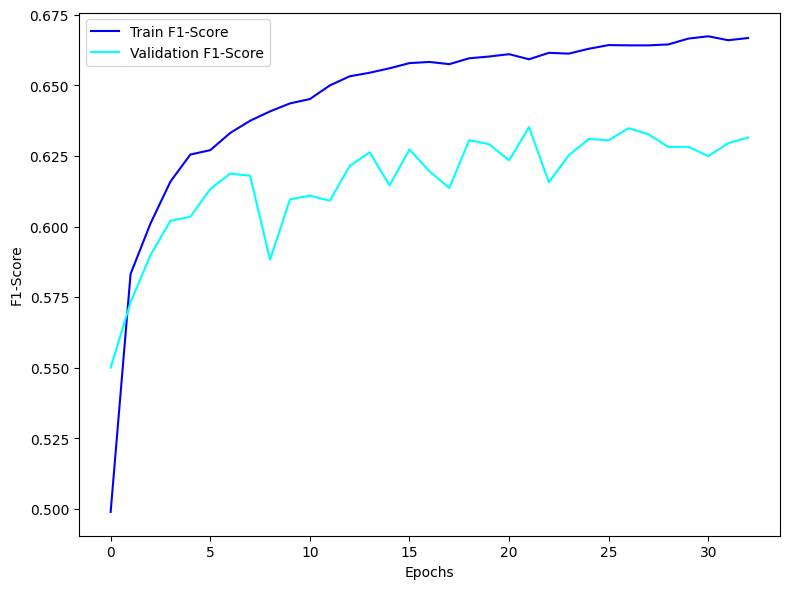

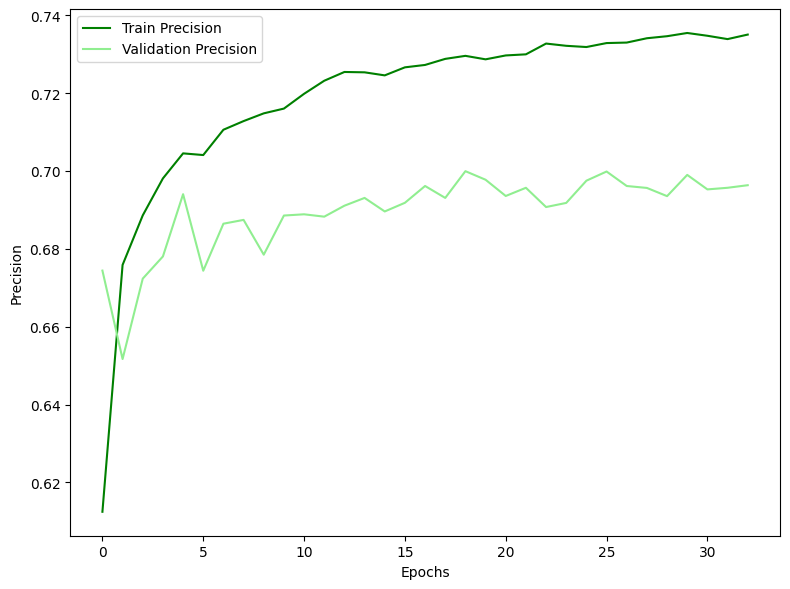

done1


In [11]:
# ==========================================================
# PLOT LEARNING CURVES (Loss, F1-Score, Precision)
# ==========================================================
print("start")

# 1. Loss Curve
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig("InceptionV3_balanced_Loss_Curve3.pdf", format='pdf', bbox_inches='tight')
plt.show()

# 2. F1 Score Curve
plt.figure(figsize=(8, 6))
plt.plot(history.history['f1_score'], label='Train F1-Score', color='blue')
plt.plot(history.history['val_f1_score'], label='Validation F1-Score', color='cyan')

plt.xlabel('Epochs')
plt.ylabel('F1-Score')
plt.legend()
plt.tight_layout()
plt.savefig("InceptionV3_balanced_F1_Curve3.pdf", format='pdf', bbox_inches='tight')
plt.show()

# 3. Precision Curve
plt.figure(figsize=(8, 6))
plt.plot(history.history['precision'], label='Train Precision', color='green')
plt.plot(history.history['val_precision'], label='Validation Precision', color='lightgreen')

plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.savefig("InceptionV3_balanced_Precision_Curve3.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("done1")

In [12]:
# ==========================================================
# EVALUATION (Training, Validation & Testing)
# ==========================================================
print("Evaluating on Training Set...")
train_results = model.evaluate(train_generator)

print("\nEvaluating on Validation Set...")
val_results = model.evaluate(val_generator)

print("\nEvaluating on Testing Set (Truly Unseen)...")
test_results = model.evaluate(test_generator)

# Unpacking 5 values based on the compile metrics order
# Order: [loss, accuracy, f1_score, precision, recall]
train_loss = train_results[0]
train_acc = train_results[1]
train_f1 = train_results[2]
train_precision = train_results[3]
train_recall = train_results[4]

val_loss = val_results[0]
val_acc = val_results[1]
val_f1 = val_results[2]
val_precision = val_results[3]
val_recall = val_results[4]

test_loss = test_results[0]
test_acc = test_results[1]
test_f1 = test_results[2]
test_precision = test_results[3]
test_recall = test_results[4]

print("\n" + "="*40)
print("TRAINING METRICS")
print("="*40)
print(f"Training Loss      : {train_loss:.4f}")
print(f"Training Accuracy  : {train_acc*100:.2f}%")
print(f"Training F1-Score  : {train_f1*100:.2f}%")
print(f"Training Precision : {train_precision*100:.2f}%")
print(f"Training Recall    : {train_recall*100:.2f}%")

print("\n" + "="*40)
print("VALIDATION METRICS")
print("="*40)
print(f"Validation Loss      : {val_loss:.4f}")
print(f"Validation Accuracy  : {val_acc*100:.2f}%")
print(f"Validation F1-Score  : {val_f1*100:.2f}%")
print(f"Validation Precision : {val_precision*100:.2f}%")
print(f"Validation Recall    : {val_recall*100:.2f}%")

print("\n" + "="*40)
print("TESTING METRICS (UNSEEN DATA)")
print("="*40)
print(f"Testing Loss      : {test_loss:.4f}")
print(f"Testing Accuracy  : {test_acc*100:.2f}%")
print(f"Testing F1-Score  : {test_f1*100:.2f}%")
print(f"Testing Precision : {test_precision*100:.2f}%")
print(f"Testing Recall    : {test_recall*100:.2f}%")

Evaluating on Training Set...
563/563 [==============================] - 129s 228ms/step - loss: 0.7239 - accuracy: 0.6655 - f1_score: 0.6592 - precision: 0.7284 - recall: 0.5618

Evaluating on Validation Set...
93/93 [==============================] - 21s 227ms/step - loss: 0.7749 - accuracy: 0.6391 - f1_score: 0.6352 - precision: 0.6957 - recall: 0.5336

Evaluating on Testing Set (Truly Unseen)...
92/92 [==============================] - 28s 297ms/step - loss: 0.7876 - accuracy: 0.6310 - f1_score: 0.6273 - precision: 0.6936 - recall: 0.5199

TRAINING METRICS
Training Loss      : 0.7239
Training Accuracy  : 66.55%
Training F1-Score  : 65.92%
Training Precision : 72.84%
Training Recall    : 56.18%

VALIDATION METRICS
Validation Loss      : 0.7749
Validation Accuracy  : 63.91%
Validation F1-Score  : 63.52%
Validation Precision : 69.57%
Validation Recall    : 53.36%

TESTING METRICS (UNSEEN DATA)
Testing Loss      : 0.7876
Testing Accuracy  : 63.10%
Testing F1-Score  : 62.73%
Testing Pre

In [13]:
# ==========================================================
# PRECISION, RECALL, F1-SCORE (Test Set - Unseen Data)
# ==========================================================
print("\nCalculating Precision, Recall, F1-score on Test Set...")

predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report (Test Set):\n")
print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

print("done1")


Calculating Precision, Recall, F1-score on Test Set...
92/92 [==============================] - 21s 222ms/step

Classification Report (Test Set):

              precision    recall  f1-score   support

      Benign       0.52      0.50      0.51       888
   Malignant       0.68      0.65      0.66      1266
      Normal       0.67      0.75      0.71       789

    accuracy                           0.63      2943
   macro avg       0.62      0.63      0.63      2943
weighted avg       0.63      0.63      0.63      2943

done1


Generating Confusion Matrix...


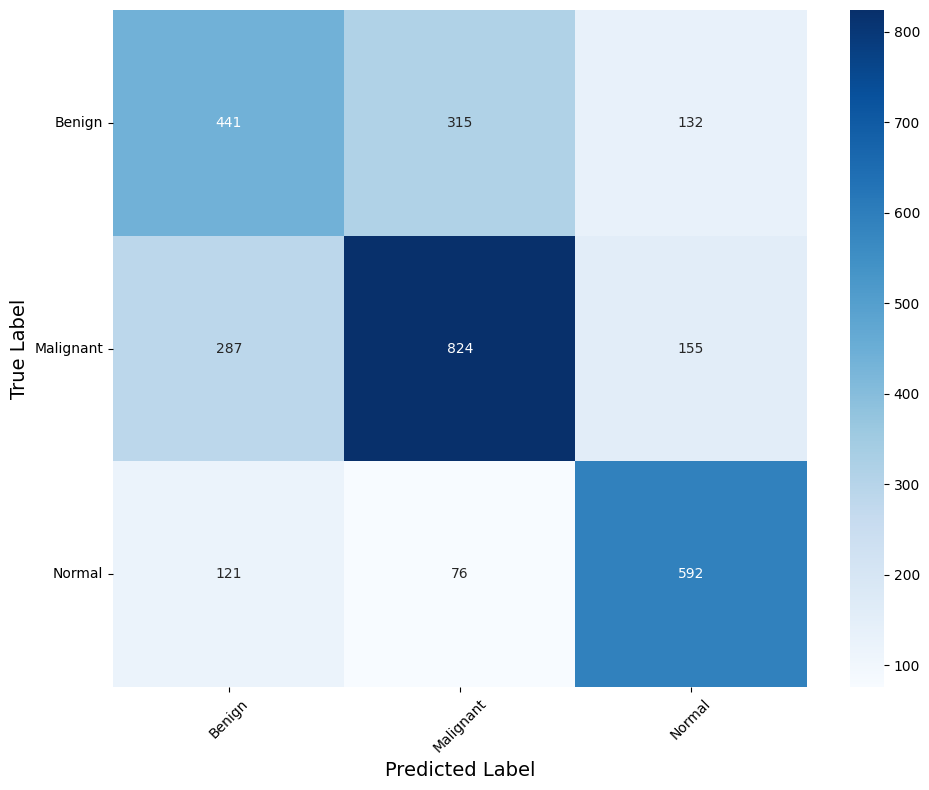

done1


In [14]:
# ==========================================================
# CONFUSION MATRIX (Test Set)
# ==========================================================
print("Generating Confusion Matrix...")

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes, predicted_classes)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,       # Show the actual numbers inside the squares
    fmt='d',          # Format as whole numbers (integers)
    cmap='Blues',     # Color scheme
    xticklabels=class_names,
    yticklabels=class_names
)

plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(rotation=45) # Rotate x-axis labels so they are easier to read
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("InceptionV3 Balanced confusion_matrix_test_V3.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("done1")